# Using the Custom Dataset Object

This notebook entails the main features of our custom-made dataset object.

This makes ResNet development much easier, and allows for more customization as well as manipulating the data structure to our benefit.

In [123]:
# Configuration file for the project (directories)
from config import *
from utils import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# A Global Overview

We wanted to be able to evolve this project sequentially. That will most likely imply the progressive increase in difficulty for both discriminator and generator. In order to do so, there are multiple essential features to take into consideration:

1. Fast and convenient data observation
2. Trivial fold manipulation
3. Easy labeling setup
4. Automatically fulfilling ResNet structural requirements 




## Directory Structure Convention

The `config.py` script assumes the following project structure:


``` raw
parent_directory/
├── DeepFake-Image-Generation-And-Detection/        <- repository
│   ├── config.py
│   └── ...
│
└── deepfake_data/
    ├── wiki/
    │   ├── 00/
    │   │   ├── image_001.jpg
    │   │   ├── image_002.jpg
    │   │   └── ...
    │   ├── 01/
    │   ├── 02/
    │   ├── ...
    │   └── 99/
    ├── inpainting/
    ├── insight/
    └── text2img/

```


Dataset creation follows the constants setup in the afforementioned script. 

## Creating an Instance

Creating a raw instance by passing a directory will read every image with the approved extensions (see in [utils.py](utils.py))

```py

def __init__(self, img_dir, label, transform=resnetFormat(), range_folds=[0,5], interval=True)

```

In [124]:
ds_fold0 = DeepFakeDataset(WIKI_DIR, "true_image", range_folds=[0], interval=False)

Building ../deepfake_data/wiki dataset with 1 folds: 100%|██████████| 1/1 [00:00<00:00, 666.50it/s]


The main functions return basic information, such as the item itself and the entire dataset's length (`__getitem__`, `__len__`).

It's important to mention that each instance is composed of its numpy array image representation, label, fold identifier and the file name from which the information is derived. These all have a formatted output which can be obtained by using  

```py 
show(self, idx)
```

In [125]:
len(ds_fold0)

281

true_image 00 10049200_1891-09-16_1958.jpg


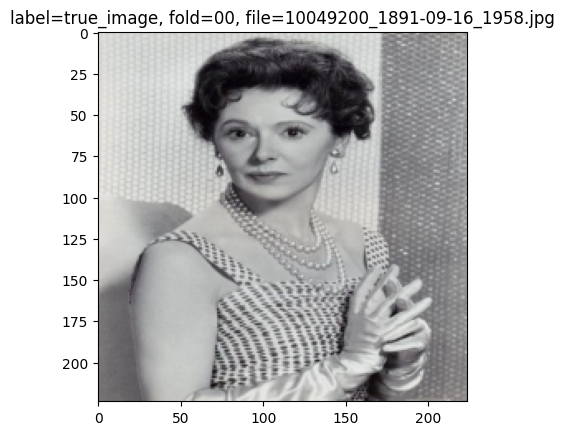

img_shape=torch.Size([3, 224, 224]), img_type=<class 'torch.Tensor'>, label=true_image, fold=00, file=10049200_1891-09-16_1958.jpg


In [126]:
img, label, fold, filename = ds_fold0[0]

print(label, fold, filename)

img_check = ds_fold0.show(0)

## Building Dataset Based on Folds

Here, we're going to be using the rationale of the following function:



```py 
def buildDsFolds(img_dir, range_folds=[0,5], label=0, transform=resnetFormat(), range=True): 
```


For starters, fold operations:
1. To include the entire dataset, use `range_folds = [0,100]`
2. To inlcude sequential subsample of the dataset, spanning from `folds_start` to `folds_end` use `range_folds = [folds_start,range_folds]`
3. To include a specific subset of scattered folds, pass folds as integer inside `range_folds` and disable `range` (`range=False`)

Regarding labeling:
1. Combine the afforementioned techniques with manual labeling and posterior `ConcatDataset(datasets)`

And formatting:
1. Implicitly applies transformation to tensor as well as resizing (for consistency and computational efficiency)

Ultimately, this process was directly dependent on concatenating multiple datasets, but this implicitly removes all of the class's inner functions, which is a huge handicap. For this reason this process was implemented directly into the dataset's `__init__` logic

In [127]:
ds_wiki = DeepFakeDataset(WIKI_DIR, 0, range_folds=[0,100])

Building ../deepfake_data/wiki dataset with 100 folds: 100%|██████████| 100/100 [00:00<00:00, 911.56it/s]


As can be seen, it's quite fast! Let's check standard properties:

In [128]:
len(ds_wiki)

30000

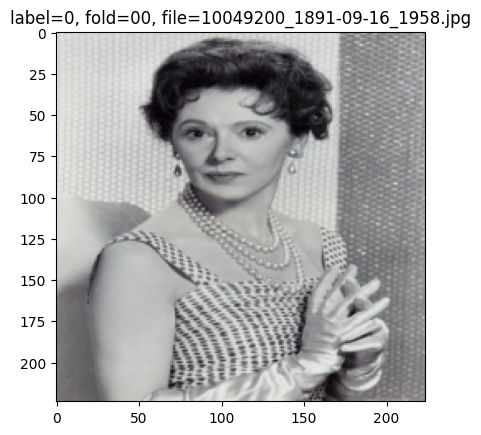

img_shape=torch.Size([3, 224, 224]), img_type=<class 'torch.Tensor'>, label=0, fold=00, file=10049200_1891-09-16_1958.jpg


In [129]:
img_wiki = ds_wiki.show(0)

This allows for simple, straightforward and controllable creation of objects with useful functions based on entire datasets given, `WIKI`, `INPAINTING`, `INSIGHT` and `TEXT2IMG`.

For the creation of the datasets to be passed onto the ResNet, when combining folds of any folder, **we do lose those inner functions**, but retain everything needed to train and test.

## Loading into ResNet

Whenever possible, use CUDA

In [130]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


### Train-Test Split and Dataset Concatenation

Concatenation here is fine because it retains every function needed for the ResNet, but we do lose the `show()` capabilities

In [131]:
ds_wiki_train = DeepFakeDataset(WIKI_DIR, 0, range_folds=[0,8])
ds_inpainting_train = DeepFakeDataset(INPAINTING_DIR, 1, range_folds=[0,8])

train_ds = ConcatDataset([ds_wiki_train, ds_inpainting_train])

ds_wiki_test = DeepFakeDataset(WIKI_DIR, 0, range_folds=[8,10])
ds_inpainting_test = DeepFakeDataset(INPAINTING_DIR, 1, range_folds=[8,10])

test_ds = ConcatDataset([ds_wiki_test, ds_inpainting_test])


ds_wiki_val = DeepFakeDataset(WIKI_DIR, 0, range_folds=[10,11])
ds_inpainting_val = DeepFakeDataset(INPAINTING_DIR, 1, range_folds=[10,11])

val_ds = ConcatDataset([ds_wiki_val, ds_inpainting_val])

Building ../deepfake_data/wiki dataset with 8 folds: 100%|██████████| 8/8 [00:00<00:00, 840.31it/s]
Building ../deepfake_data/inpainting dataset with 8 folds: 100%|██████████| 8/8 [00:00<00:00, 840.71it/s]
Building ../deepfake_data/wiki dataset with 2 folds: 100%|██████████| 2/2 [00:00<00:00, 661.77it/s]
Building ../deepfake_data/inpainting dataset with 2 folds: 100%|██████████| 2/2 [00:00<00:00, 1000.07it/s]
Building ../deepfake_data/wiki dataset with 1 folds: 100%|██████████| 1/1 [00:00<00:00, 500.51it/s]
Building ../deepfake_data/inpainting dataset with 1 folds: 100%|██████████| 1/1 [00:00<00:00, 665.76it/s]


The next step is to create dataloaders to properly pass information to the ResNet. Let's also check what's being passed to the ResNet

batch image tensor shape: torch.Size([16, 3, 224, 224])
batch label tensor shape: torch.Size([16])
first sample: 0 06 8112306_1988-04-19_2014.jpg
resnet sees: torch.Size([3, 224, 224]) -> [C, H, W]
matplotlib sees: (224, 224, 3) -> [H, W, C]


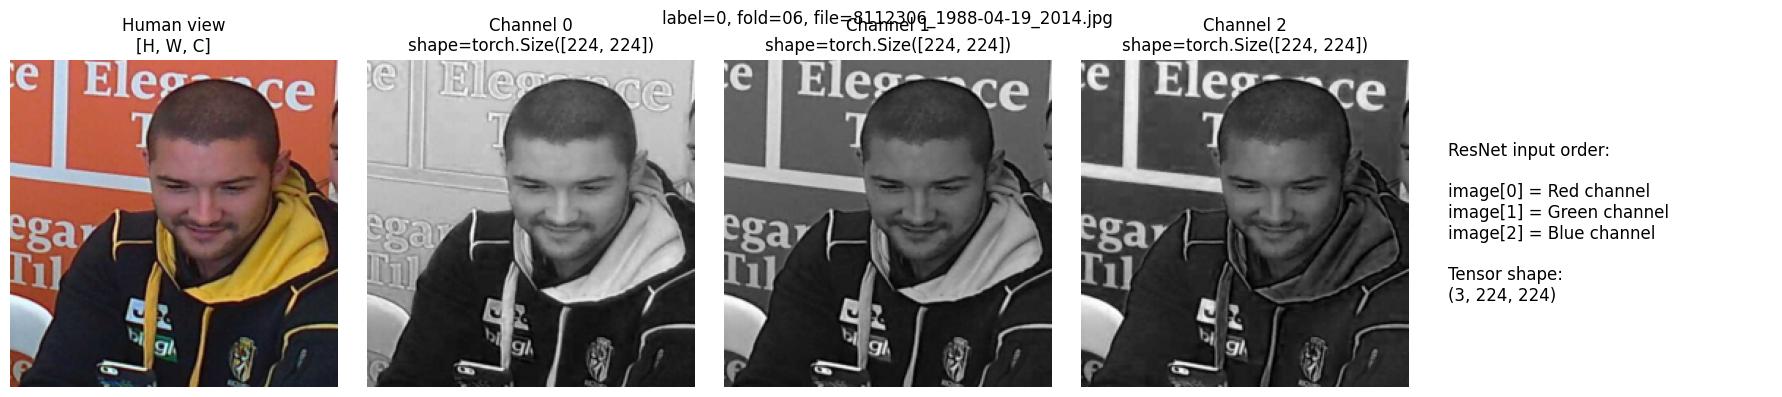

In [134]:
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=16, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
showResNetVision(loader)

Let's do a quick test run

In [79]:
# Model setup

model = resnet18(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [80]:
# Training 

n_epochs = 5

for epoch in range(n_epochs):

    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (images, labels, folds, fnames) in enumerate(tqdm(train_loader, desc=f"Train epoch {epoch+1}")):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        if batch_idx == 0:
            print("train batch:", images.shape, outputs.shape, "loss:", loss.item())

    print(f"epoch {epoch+1} train_loss={train_loss/train_total:.4f} train_acc={train_correct/train_total:.4f}")


Train epoch 1:   0%|          | 1/297 [00:01<05:29,  1.11s/it]

train batch: torch.Size([16, 3, 224, 224]) torch.Size([16, 2]) loss: 0.6748799085617065


Train epoch 1: 100%|██████████| 297/297 [00:49<00:00,  5.97it/s]


epoch 1 train_loss=0.7265 train_acc=0.4987


Train epoch 2:   0%|          | 1/297 [00:00<00:29,  9.98it/s]

...

epoch 4 train_loss=0.6849 train_acc=0.5570


Train epoch 5:   1%|          | 2/297 [00:00<00:24, 12.17it/s]

train batch: torch.Size([16, 3, 224, 224]) torch.Size([16, 2]) loss: 0.690553605556488


Train epoch 5: 100%|██████████| 297/297 [00:21<00:00, 13.99it/s]

epoch 5 train_loss=0.6740 train_acc=0.5800


In [81]:
# Model performance assessment

model.eval()
test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for batch_idx, (images, labels, folds, fnames) in enumerate(tqdm(test_loader, desc="Test")):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

        if batch_idx == 0:
            print("test batch:", images.shape, outputs.shape)

print(f"test_loss={test_loss/test_total:.4f} test_acc={test_correct/test_total:.4f}")

Test:   3%|▎         | 2/76 [00:00<00:10,  7.27it/s]

test batch: torch.Size([16, 3, 224, 224]) torch.Size([16, 2])


Test: 100%|██████████| 76/76 [00:13<00:00,  5.77it/s]

test_loss=0.7316 test_acc=0.5308
